Download completed!
Extracting dataset...


/tmp/ipykernel_1940/709198442.py:54: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(extract_path)


Extraction completed!
Image directory: /content/dog_images/Images
Number of breeds: 120
Found 16508 images belonging to 120 classes.
Found 4072 images belonging to 120 classes.
Number of classes: 120
Number of training images: 16508
Number of validation images: 4072


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 120)            │        15,480 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,437,432 (9.30 MB)

 Trainable params: 179,448 (700.97 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 798s 2s/step - accuracy: 0.4862 - loss: 2.0284 - val_accuracy: 0.7024 - val_loss: 1.0040
Epoch 2/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 781s 2s/step - accuracy: 0.6915 - loss: 1.0461 - val_accuracy: 0.7237 - val_loss: 0.9086
Epoch 3/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 792s 2s/step - accuracy: 0.7360 - loss: 0.8617 - val_accuracy: 0.7421 - val_loss: 0.8573
Epoch 4/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 780s 2s/step - accuracy: 0.7699 - loss: 0.7371 - val_accuracy: 0.7394 - val_loss: 0.8501
Epoch 5/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 781s 2s/step - accuracy: 0.7862 - loss: 0.6711 - val_accuracy: 0.7461 - val_loss: 0.8373
128/128 ━━━━━━━━━━━━━━━━━━━━ 154s 1s/step - accuracy: 0.7461 - loss: 0.8373

Validation Accuracy: 74.60707426071167 %

Starting Fine-Tuning...
Epoch 1/2
516/516 ━━━━━━━━━━━━━━━━━━━━ 956s 2s/step - accuracy: 0.7480 - loss: 0.8133 - val_accuracy: 0.7412 - val_loss: 0.8956
Epoch 2/2
516/516 ━━━━━━━━━━━━━━━━━━━━ 958s 2s/step - accuracy: 0.8114 - loss: 0.5842 - v

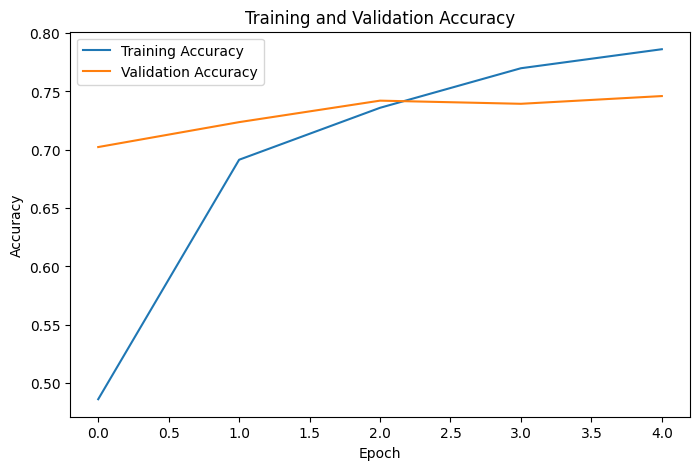

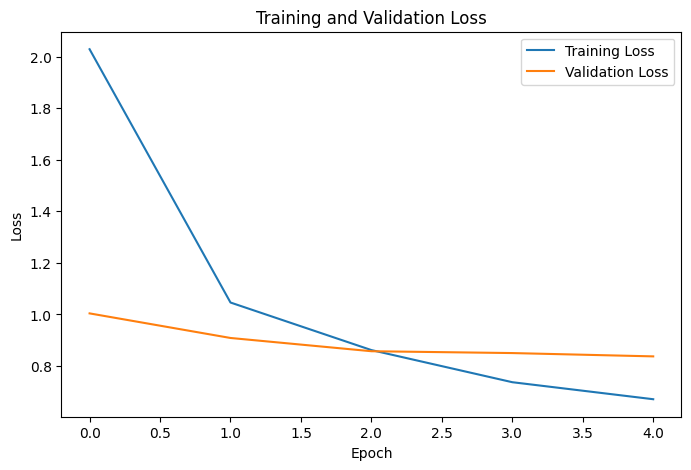

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


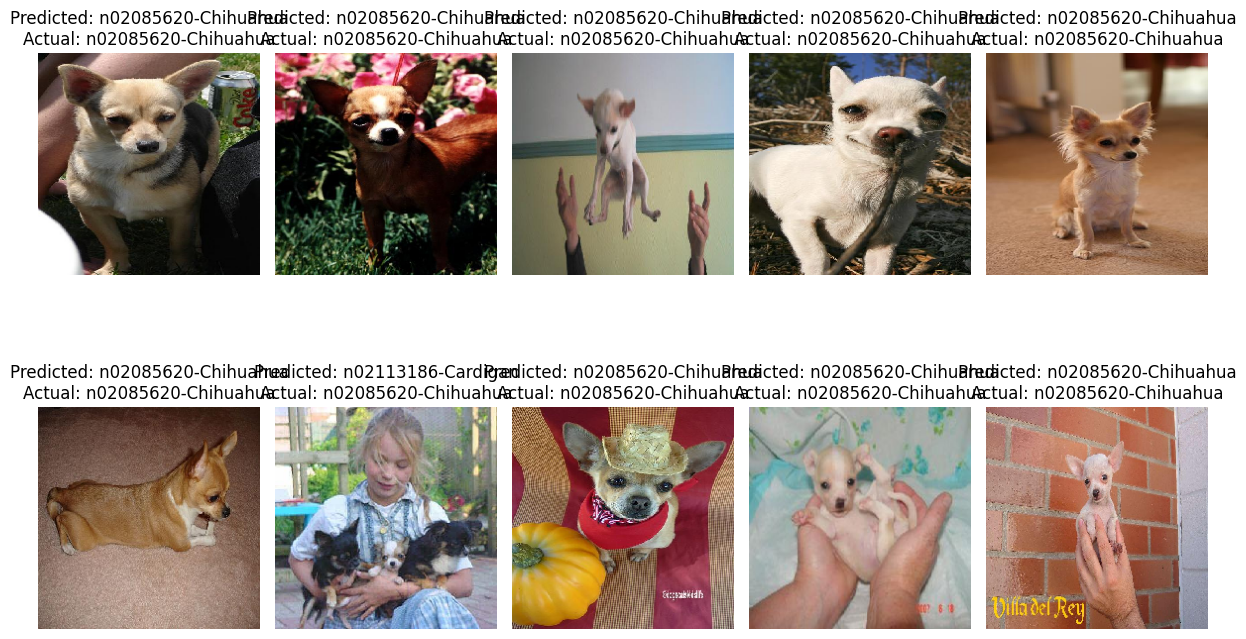

In [ ]:
# ============================================================
# DOG BREED CLASSIFICATION USING TRANSFER LEARNING
# MobileNetV2
# ============================================================

# 1. Install required libraries
!pip install -q tensorflow keras


# ============================================================
# 2. Import libraries
# ============================================================

import os
import zipfile
import urllib.request
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2


# ======
======================================================
# 3. Download Stanford Dogs dataset
# ============================================================

url = "http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar"

dataset_file = "/content/dogs.tar"

print("Downloading dataset...")

urllib.request.urlretrieve(url, dataset_file)

print("Download completed!")


# ============================================================
# 4. Extract dataset
# ============================================================

import tarfile

extract_path = "/content/dog_images"

os.makedirs(extract_path, exist_ok=True)

print("Extracting dataset...")

with tarfile.open(dataset_file, "r") as tar:
    tar.extractall(extract_path)

print("Extraction completed!")


# ============================================================
# 5. Find image directory
# ============================================================

image_path = os.path.join(
    extract_path,
    "Images"
)

print("Image directory:", image_path)

print("Number of breeds:",
      len(os.listdir(image_path)))


# ============================================================
# 6. Create training and validation generators
# ============================================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)


train_data = datagen.flow_from_directory(
    image_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)


validation_data = datagen.flow_from_directory(
    image_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)


# ============================================================
# 7. Display dataset information
# ============================================================

print("Number of classes:",
      train_data.num_classes)

print("Number of training images:",
      train_data.samples)

print("Number of validation images:",
      validation_data.samples)


# ============================================================
# 8. Load pretrained MobileNetV2
# ============================================================

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)


# Freeze pretrained layers

base_model.trainable = False


# ============================================================
# 9. Build CNN model
# ============================================================

model = models.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        train_data.num_classes,
        activation="softmax"
    )
])


# ============================================================
# 10. Compile model
# ============================================================

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


# ============================================================
# 11. Display model
# ============================================================

model.summary()


# ============================================================
# 12. Train model
# ============================================================

history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=5
)


# ============================================================
# 13. Evaluate model
# ============================================================

loss, accuracy = model.evaluate(validation_data)

print("\nValidation Accuracy:",
      accuracy * 100, "%")


# ============================================================
# 14. Fine-tuning
# ============================================================

print("\nStarting Fine-Tuning...")


base_model.trainable = True


# Freeze all except last 20 layers

for layer in base_model.layers[:-20]:
    layer.trainable = False


# Recompile model

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


# ============================================================
# 15. Fine-tune model
# ============================================================

history_fine = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=2
)


# ============================================================
# 16. Final evaluation
# ============================================================

loss, accuracy = model.evaluate(validation_data)

print("\nFinal Accuracy:",
      accuracy * 100, "%")


# ============================================================
# 17. Display accuracy graph
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.show()


# ============================================================
# 18. Display loss graph
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()


# ============================================================
# 19. Display prediction results
# ============================================================

class_names = list(
    train_data.class_indices.keys()
)

images, labels = next(validation_data)

predictions = model.predict(images)

plt.figure(figsize=(12,8))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(images[i])

    predicted = np.argmax(predictions[i])
    actual = np.argmax(labels[i])

    plt.title(
        "Predicted: " +
        class_names[predicted] +
        "\nActual: " +
        class_names[actual]
    )

    plt.axis("off")

plt.tight_layout()
plt.show()